## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

## Loading the data

In [2]:
data_path = '/data/DANE.xlsx'

In [3]:
df = pd.ExcelFile(os.getcwd() + data_path)
inks_df = df.parse('a.', header=0, index_col=0, usecols=list)#[1425:] #inKs
inds_df = df.parse('i.', header=0, index_col=0, usecols=list)#[1425:]  #inDs

In [4]:
#[1425:] rzeczywiste

## Preprocessing

### Some checks on the data

1. Let's check if column naming is consistent (inDs).

In [4]:
series_based_on_sample_name = pd.Series(inds_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [5]:
series_based_on_column = inds_df['seria'].reset_index(drop=True)

In [6]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything is fine. For inKs:

In [7]:
series_based_on_sample_name = pd.Series(inks_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [8]:
series_based_on_column = inks_df['seria'].reset_index(drop=True)

In [9]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything ok.

2. Let's check if naming is consistent across two sheets (i.e. for inDs and for inKs).

In [10]:
series_from_inds_sheet = inds_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [11]:
series_from_inks_sheet = inks_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [12]:
np.all(series_from_inds_sheet == series_from_inks_sheet)

False

It's not consistent, but it's not the problem, cause rows in both tables correspond to each other.

In [13]:
inks_df.shape == inds_df.shape

True

### Joining corresponding samples from inds and inks into one table

In [14]:
inks_df = inks_df.reset_index(drop=False)

In [15]:
inds_df = inds_df.reset_index(drop=False)

In [16]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inds', lsuffix='_inks')

In [17]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Removing some data

1. Let's remove rows with missing values.

In [18]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [19]:
inDKs_df.dropna(inplace=True)

In [20]:
inDKs_df.shape

(2415, 64)

2. Let's keep only columns that we need.

In [21]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

### Creating features and labels matrices

In [22]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [23]:
X = torch.Tensor(inDKs_df[inds_colnames].values).to(device)
y = torch.Tensor(inDKs_df[inks_colnames].values).to(device)

In [24]:
# class InksDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = X
#         self.y =y
        
#     def __getitem__(self, index):
#         return X[index, :], y[index, :]
    
#     def __len__(self):
#         assert self.X.shape[0] == self.y.shape[0]
#         return self.X.shape[0]

### Train test split

In [25]:
#15 slices from the same sample should either all go to train or all go to test

In [26]:
indices = list(range(int(X.shape[0]/15)))

ind_train, ind_test = train_test_split(indices, test_size=0.3, random_state=1)
# ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
# ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)

In [27]:
ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
ind_train_all = [x for l in ind_train_all for x in l]
ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
ind_test_all = [x for l in ind_test_all for x in l]

In [28]:
# partition = {'train': ind_train,
#             'validation': ind_val,
#             'test': ind_test}

partition = {'train': ind_train_all,
            'test': ind_test_all}

In [29]:
X_train = X[partition['train']]
y_train = y[partition['train']]

# X_val = X[partition['validation']]
# y_val = y[partition['validation']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [30]:
loader = DataLoader(list(zip(X_train, y_train)), shuffle=True, batch_size=100)
test_loader = DataLoader(list(zip(X_test, y_test)))

## Building neural network

In [31]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(29, 50),
        nn.Dropout(),
        nn.ReLU(),
        nn.Linear(50,29))
    def forward(self, x):
        return self.seq(x)

## Training

In [32]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=29, out_features=50, bias=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=50, out_features=29, bias=True)
  )
)


In [33]:
def train_one_epoch(loader, epoch_index):
    running_loss = 0.
    last_loss = 0.

    for i, data in enumerate(loader):

        inputs, labels = data

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
#         if i % loader.batch_size == (loader.batch_size - 1):
#             last_loss = running_loss / loader.batch_size # loss per batch
#             print('  batch {} loss: {}'.format(i + 1, last_loss))
#             tb_x = epoch_index * len(training_loader) + i + 1
#             tb_writer.add_scalar('Loss/train', last_loss, tb_x)
#             running_loss = 0.
    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [34]:
# Initializing in a separate cell so we can easily add more epochs to the same run
# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 200

loss_fn = nn.L1Loss()
#optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(loader, epoch_number)


    running_tloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(test_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_tloss += loss

    avg_tloss = running_tloss / (i + 1)
    print('LOSS train {} test {}'.format(avg_loss, avg_tloss))
    
    train_losses.append(avg_loss)
    test_losses.append(avg_tloss)
    test_losses = [float(a) for a in test_losses]

    epoch_number += 1

EPOCH 1:
LOSS train 7.296844790963566 test 9.492918014526367
EPOCH 2:
LOSS train 7.233328454634723 test 9.200783729553223
EPOCH 3:
LOSS train 7.052433350506951 test 8.94066333770752
EPOCH 4:
LOSS train 7.013750160441679 test 8.708663940429688
EPOCH 5:
LOSS train 6.827271405388327 test 8.496050834655762
EPOCH 6:
LOSS train 6.812032952028162 test 8.311737060546875
EPOCH 7:
LOSS train 6.680575062246883 test 8.1419095993042
EPOCH 8:
LOSS train 6.600602963391473 test 7.986297607421875
EPOCH 9:
LOSS train 6.572654976564295 test 7.848210334777832
EPOCH 10:
LOSS train 6.47606159658993 test 7.746727466583252
EPOCH 11:
LOSS train 6.411225599401138 test 7.66737174987793
EPOCH 12:
LOSS train 6.381827130037196 test 7.593027114868164
EPOCH 13:
LOSS train 6.339719071107752 test 7.517245292663574
EPOCH 14:
LOSS train 6.276053933536305 test 7.445546627044678
EPOCH 15:
LOSS train 6.2482406672309425 test 7.373474597930908
EPOCH 16:
LOSS train 6.211567864698522 test 7.30542516708374
EPOCH 17:
LOSS train 6

LOSS train 4.22261381149292 test 6.717411041259766
EPOCH 134:
LOSS train 4.231920859392951 test 6.71640157699585
EPOCH 135:
LOSS train 4.2185213145087745 test 6.718513488769531
EPOCH 136:
LOSS train 4.250849134781781 test 6.733460426330566
EPOCH 137:
LOSS train 4.203011302387013 test 6.746409893035889
EPOCH 138:
LOSS train 4.202092899995692 test 6.770205020904541
EPOCH 139:
LOSS train 4.194170082316679 test 6.780425071716309
EPOCH 140:
LOSS train 4.209297762197607 test 6.8062920570373535
EPOCH 141:
LOSS train 4.186891667983112 test 6.830062389373779
EPOCH 142:
LOSS train 4.193502832861507 test 6.855128765106201
EPOCH 143:
LOSS train 4.1803129140068505 test 6.863154888153076
EPOCH 144:
LOSS train 4.140053440542782 test 6.8697075843811035
EPOCH 145:
LOSS train 4.180018985972685 test 6.89772367477417
EPOCH 146:
LOSS train 4.183802927241606 test 6.921653747558594
EPOCH 147:
LOSS train 4.15402486745049 test 6.944869041442871
EPOCH 148:
LOSS train 4.198617318097283 test 6.956825256347656
EPO

In [35]:
np.array(outputs.cpu())

array([[3.9065709e+00, 2.1898430e+01, 3.9645705e-01, 5.4731655e+00,
        5.3226304e-01, 4.8966687e-02, 5.3922474e-02, 8.2105212e-02,
        5.0414154e+01, 3.0579448e-02, 3.0539641e-01, 5.5191875e-03,
        3.6880124e-02, 1.5707140e+00, 1.9323677e-02, 1.3026385e-02,
        3.2475406e-01, 5.0968964e-02, 1.1726837e-03, 4.0492978e-02,
        9.6348032e-02, 1.1002585e-02, 1.0192105e-02, 1.0641711e-03,
        4.9070287e-02, 1.0723288e-02, 4.0612407e-03, 1.9476602e-02,
        8.0592215e-01]], dtype=float32)

In [36]:
np.array(labels.cpu())

array([[1.4845043e+01, 1.1827298e+02, 9.4743031e-01, 1.6472683e+01,
        8.5692900e-01, 7.6834247e-02, 1.8786803e-01, 6.6032737e-01,
        2.9496945e+02, 1.7606318e-01, 1.2356540e+00, 1.4379831e-02,
        4.8915874e-02, 5.2330327e+00, 4.3370728e-03, 1.5960442e-02,
        1.9671342e+00, 7.6911449e-01, 6.2967889e-04, 1.2844856e-01,
        4.0777841e-01, 5.5951800e-02, 9.3680853e-03, 1.9661409e-03,
        5.0053217e-02, 4.9015948e-01, 4.0093851e-03, 3.5403781e-02,
        5.9253758e-01]], dtype=float32)

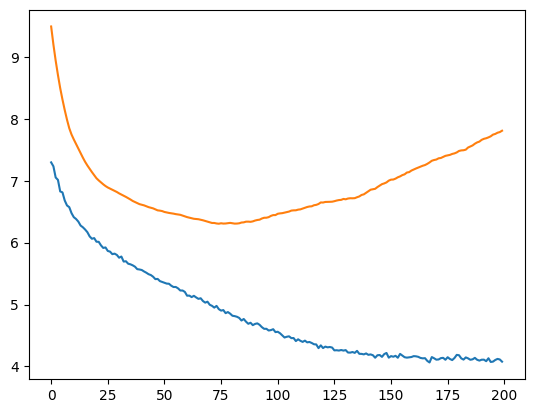

In [38]:
plt.plot(train_losses)
plt.plot(test_losses)
#plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Dropout(),
# nn.Linear(50,29))

#lr 0.0001
#batch size 100
#Adam
#tylko rzeczywiste

(0.0, 250.0)

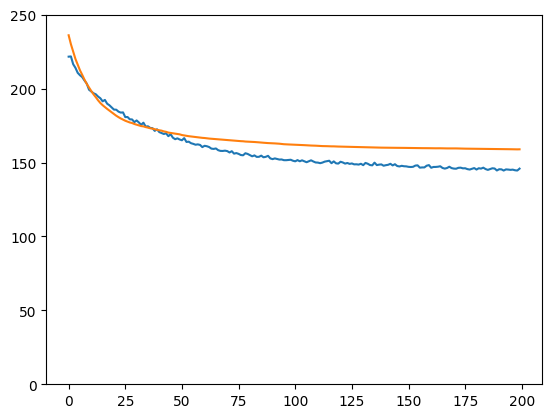

In [173]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Dropout(),
# nn.Linear(50,29))

#lr 0.0001
#batch size 100
#Adam

(0.0, 250.0)

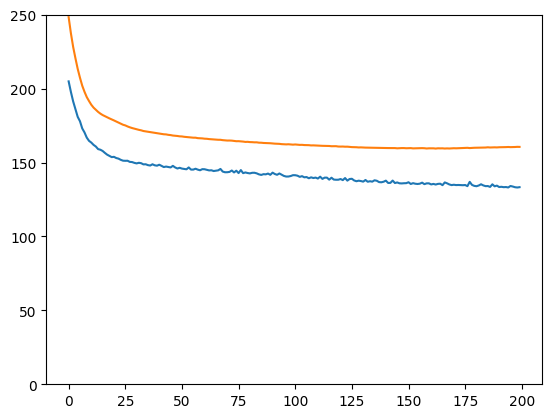

In [165]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Linear(50,29))

#lr 0.0001
#batch size 100
#Adam

(0.0, 250.0)

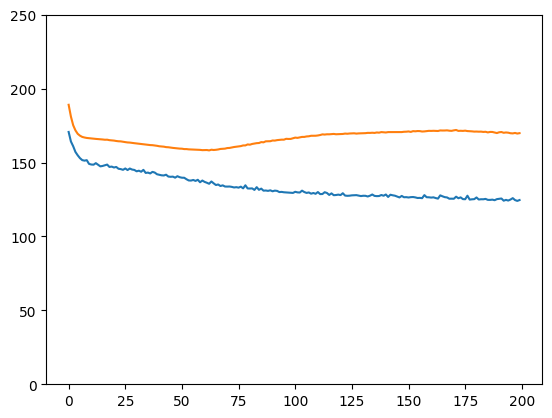

In [151]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Linear(50,100),
# nn.ReLU(),
# nn.Linear(100,29))

#lr 0.0001
#batch size 100
#Adam

(0.0, 250.0)

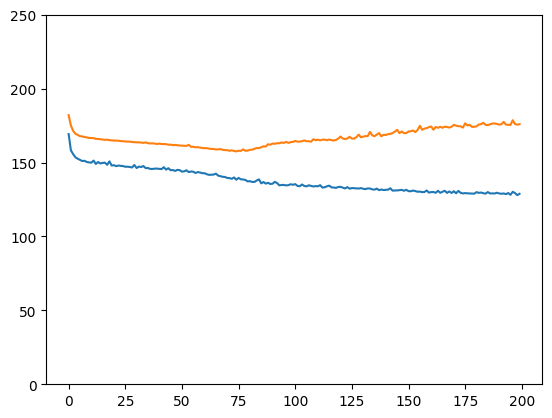

In [114]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Linear(50,100),
# nn.ReLU(),
# nn.Linear(100,29))

#lr 0.0001
#batch size 100
#SGD

## Interpretability